### Rudraksh Sindwani                          SIT720


# Part B: Problem Solving Practical Task

## Question 1: Linear SVM

### Discussion

The Bank Marketing dataset was loaded to predict whether a customer subscribed to a term deposit. The target variable `y` has two classes: yes and no.

The dataset contains numerical and categorical variables. The categorical variables were changed into numerical values using One-Hot Encoding. The data was divided into training and testing sets using stratified sampling because the target classes are not balanced. Standard Scaling was then applied to the features.

A Support Vector Machine with a linear kernel and the default value of `C = 1.0` was used. Accuracy precision recall and F1-score were used to measure the model performance.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

bank = pd.read_csv("bank-additional-full.csv", sep=";")
print("\nTarget variable:")
print(bank["y"].value_counts())


Target variable:
y
no     36548
yes     4640
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = bank.drop("y", axis=1)
y = bank["y"].map({"no": 0, "yes": 1})

# One-Hot Encoding
Xencoded = pd.get_dummies(X, drop_first=True)

print("Features after encoding:", Xencoded.shape[1])

# Split data into training and testing sets
Xtrain, Xtest, ytrain, ytest = train_test_split(
    Xencoded,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print("Training samples:", Xtrain.shape[0])
print("Testing samples:", Xtest.shape[0])


# Standard Scaling
sc = StandardScaler()
sc.fit(Xtrain)

X_train_std = sc.transform(Xtrain)
X_test_std = sc.transform(Xtest)

print("Scaled training shape:", X_train_std.shape)
print("Scaled testing shape:", X_test_std.shape)

Features after encoding: 53
Training samples: 32950
Testing samples: 8238
Scaled training shape: (32950, 53)
Scaled testing shape: (8238, 53)


In [16]:
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix)

# Linear SVM with default C = 1.0
svm_linear = SVC(kernel="linear",C=1.0,random_state=0)

# Train model
svm_linear.fit(X_train_std, ytrain)

# Predictions
ypred = svm_linear.predict(X_test_std)

# Performance metrics
accuracy = accuracy_score(ytest, ypred)
precision = precision_score(ytest, ypred)
recall = recall_score(ytest, ypred)
f1 = f1_score(ytest, ypred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(ytest, ypred))

Accuracy: 0.9031318281136198
Precision: 0.6504629629629629
Recall: 0.30280172413793105
F1-score: 0.41323529411764703

Confusion Matrix:
[[7159  151]
 [ 647  281]]


## Result

The Linear SVM model with the default C = 1.0 achieved an accuracy of 90.31%. The precision was 65.05% and the recall was 30.28%. The F1 score was 41.32%.

The confusion matrix shows that the model correctly classified 7159 customers who did not subscribe and 281 customers who subscribed. However 647 customers who subscribed were incorrectly classified as not subscribing.

The model has high accuracy but low recall. This happens because the dataset has many more customers who did not subscribe than customers who subscribed. The model therefore needs further improvement for detecting the smaller class.

# Question 2: Testing Different C Values

## Discussion

The C value controls the balance between a large margin and classification errors. A large C gives more importance to correctly classifying the training data. A small C allows more errors so the model can keep a larger margin.

Different C values were tested using the same training and testing data from Question 1. Accuracy and F1 score were used to compare the models. The C value with the best F1 score was selected as the optimal value.

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Different C values
C_values = [ 0.1,1, 10]
results = []

for c in C_values:
    model = SVC(kernel="linear",C=c,random_state=0,cache_size=2000)
    
    model.fit(Xtrain, ytrain)
    ypred_c = model.predict(Xtest)
    
    accuracy_c = accuracy_score(ytest, ypred_c)
    f1_c = f1_score(ytest, ypred_c)
    results.append([c, accuracy_c, f1_c])

results_df = pd.DataFrame(results,columns=["C", "Accuracy", "F1-score"])
print(results_df)

# Find the best C using F1score
best_index = results_df["F1-score"].idxmax()
best_C = results_df.loc[best_index, "C"]
print("\nBest C:", best_C)
print("Best F1-score:",results_df.loc[best_index, "F1-score"])

      C  Accuracy  F1-score
0   0.1  0.901554  0.396128
1   1.0  0.861860  0.440511
2  10.0  0.860889  0.440430

Best C: 1.0
Best F1-score: 0.44051130776794495


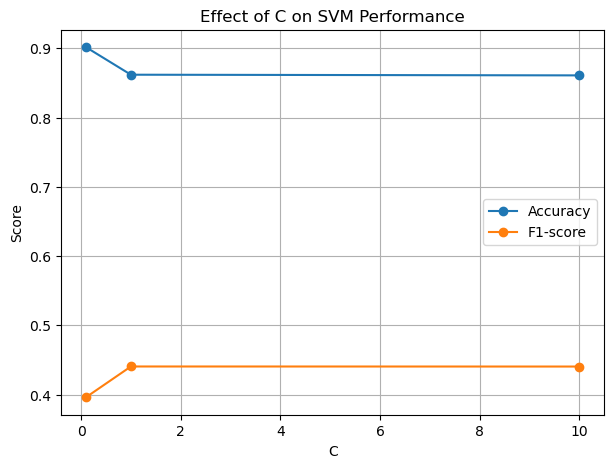

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(results_df["C"],results_df["Accuracy"], marker="o",label="Accuracy")
plt.plot(results_df["C"],results_df["F1-score"],marker="o",label="F1-score")
plt.xlabel("C")
plt.ylabel("Score")
plt.title("Effect of C on SVM Performance")
plt.legend()
plt.grid(True)
plt.show()

      C    Margin
0   0.1  4.075260
1   1.0  4.008549
2  10.0  3.285605


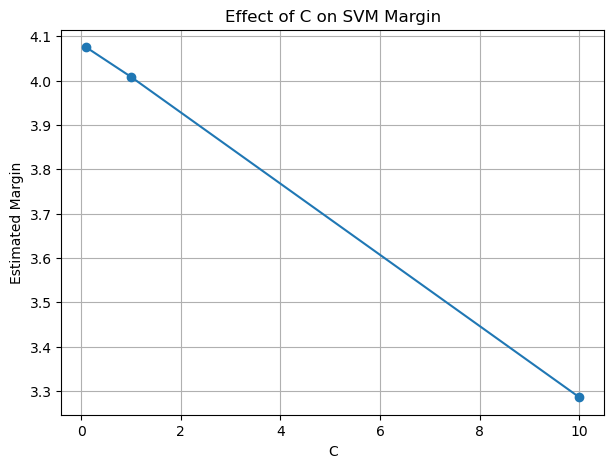

In [20]:
from sklearn.svm import LinearSVC

margin_results = []

for c in C_values:
    model = LinearSVC(C=c,random_state=0,max_iter=5000)

    model.fit(Xtrain, ytrain)
    w = model.coef_[0]
    margin = 1 / np.linalg.norm(w)

    margin_results.append([c, margin])

margin_df = pd.DataFrame(margin_results,columns=["C", "Margin"])
print(margin_df)

plt.figure(figsize=(7, 5))
plt.plot(margin_df["C"],margin_df["Margin"],marker="o")
plt.xlabel("C")
plt.ylabel("Estimated Margin")
plt.title("Effect of C on SVM Margin")
plt.grid(True)
plt.show()

## Result

Different C values were tested to compare the SVM performance. The best F1 score was 0.441 when C was 1.0. This was the same as the default C value used in Question 1.

The accuracy was highest at C = 0.1 with a value of 0.902. However the F1-score was lower at 0.396. Therefore C = 1.0 was selected because it gave the highest F1 score.

The margin was 4.075 for C = 0.1, 4.009 for C = 1.0 and 3.286 for C = 10. The plot shows that the margin became smaller when C increased. In this case the optimal C was not different from the default C so the margin did not change from Question 1.

# Question 3: RBF and Polynomial Kernels

## Discussion

In this question the RBF and Polynomial kernels are tested using the same training and testing data. The RBF kernel can create a curved boundary when the data is not easy to separate with a straight line. The Polynomial kernel can also create a curved boundary based on its degree.

Different values of C and gamma are tested for the RBF kernel. Different values of C and degree are tested for the Polynomial kernel. The F1score is used to compare the models because the Bank Marketing dataset has an uneven class distribution.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Take a smaller balanced sample from training data for tuning
X_tune, _, y_tune, _ = train_test_split(Xtrain,ytrain,train_size=8000,random_state=0,stratify=ytrain)

print("Tuning data:", X_tune.shape)

# RBF tuning
C_values = [0.1, 1, 10]
gamma_values = ["scale", 0.1]
rbf_results = []

for c in C_values:
    for gamma in gamma_values:

        model = SVC(kernel="rbf",C=c,gamma=gamma,cache_size=2000)
        model.fit(X_tune, y_tune)

        ypred_rbf = model.predict(Xtest)

        accuracy = accuracy_score(ytest, ypred_rbf)
        f1 = f1_score(ytest, ypred_rbf)

        rbf_results.append([c, gamma, accuracy, f1])

rbf_df = pd.DataFrame(rbf_results,columns=["C", "Gamma", "Accuracy", "F1-score"])
print(rbf_df)

best_rbf_index = rbf_df["F1-score"].idxmax()
best_rbf = rbf_df.loc[best_rbf_index]

print("\nBest RBF setting:")
print(best_rbf)

Tuning data: (8000, 53)
      C  Gamma  Accuracy  F1-score
0   0.1  scale  0.887351  0.000000
1   0.1    0.1  0.887351  0.000000
2   1.0  scale  0.895970  0.311647
3   1.0    0.1  0.887109  0.000000
4  10.0  scale  0.897669  0.348028
5  10.0    0.1  0.885773  0.010515

Best RBF setting:
C               10.0
Gamma          scale
Accuracy    0.897669
F1-score    0.348028
Name: 4, dtype: object


In [23]:
# Polynomial kernel tuning
degree_values = [2, 3]
C_values = [0.1, 1, 10]

poly_results = []

for c in C_values:
    for degree in degree_values:

        model = SVC(kernel="poly",C=c,degree=degree,gamma="scale",cache_size=2000)
        model.fit(X_tune, y_tune)

        ypred_poly = model.predict(Xtest)

        accuracy = accuracy_score(ytest, ypred_poly)
        f1 = f1_score(ytest, ypred_poly)

        poly_results.append([c, degree, accuracy, f1])

poly_df = pd.DataFrame(poly_results,columns=["C", "Degree", "Accuracy", "F1-score"])
print(poly_df)

best_poly_index = poly_df["F1-score"].idxmax()
best_poly = poly_df.loc[best_poly_index]

print("\nBest Polynomial setting:")
print(best_poly)

      C  Degree  Accuracy  F1-score
0   0.1       2  0.887230  0.000000
1   0.1       3  0.887473  0.008556
2   1.0       2  0.895727  0.312250
3   1.0       3  0.896577  0.328076
4  10.0       2  0.898398  0.359602
5  10.0       3  0.899369  0.384558

Best Polynomial setting:
C           10.000000
Degree       3.000000
Accuracy     0.899369
F1-score     0.384558
Name: 5, dtype: float64


In [24]:
# Train the best models using the full training data

# Linear SVM
linear_best=SVC(kernel="linear",C=1.0,random_state=0,cache_size=2000)

linear_best.fit(Xtrain, ytrain)
ypred_linear=linear_best.predict(Xtest)

# RBF SVM
rbf_best=SVC(kernel="rbf",C=10.0,gamma="scale",random_state=0,cache_size=2000)

rbf_best.fit(Xtrain,ytrain)
ypred_rbf=rbf_best.predict(Xtest)

# Polynomial SVM
poly_best =SVC(kernel="poly",C=10.0,degree=3,gamma="scale",random_state=0,cache_size=2000)

poly_best.fit(Xtrain, ytrain)
ypred_poly=poly_best.predict(Xtest)

# Final comparison on the test set
print("Linear SVM")
print("Accuracy:",accuracy_score(ytest, ypred_linear))
print("F1-score:",f1_score(ytest, ypred_linear))

print("\nRBF SVM")
print("Accuracy:",accuracy_score(ytest, ypred_rbf))
print("F1-score:",f1_score(ytest, ypred_rbf))

print("\nPolynomial SVM")
print("Accuracy:",accuracy_score(ytest, ypred_poly))
print("F1-score:",f1_score(ytest, ypred_poly))

Linear SVM
Accuracy: 0.86185967467832
F1-score: 0.44051130776794495

RBF SVM
Accuracy: 0.8958485069191552
F1-score: 0.3136

Polynomial SVM
Accuracy: 0.8959698956057296
F1-score: 0.31385108086469177


## Result

Different kernel functions were tested using the same training and test data. The best RBF model used C = 10 and gamma = scale. It achieved an accuracy of 89.58% and an F1score of 31.36%.

The best Polynomial model used C = 10 and degree = 3. It achieved an accuracy of 89.60% and an F1-score of 31.39%.

The Linear SVM with C = 1.0 achieved an accuracy of 86.19% and an F1score of 44.05%. It had the highest F1score of the three models. This shows that the Linear kernel was better at finding customers who subscribed to a term deposit. The RBF and Polynomial kernels had higher accuracy but lower F1-scores because the dataset is not balanced.